# Forecasting atmospheric CO2 with SARIMAX

A short walkthrough of the `tsforecast` package on the Mauna Loa CO2 monthly
series that ships with statsmodels, so everything here runs offline:

1. load and inspect the series
2. STL decomposition into trend, seasonal, and residual components
3. fit SARIMAX and forecast a held-out year with a confidence interval
4. walk-forward backtest with RMSE and MAPE

In [1]:
import matplotlib.pyplot as plt

from tsforecast import (
    SarimaxForecaster,
    decompose,
    load_co2_monthly,
    walk_forward_backtest,
)

series = load_co2_monthly()
print(f"{len(series)} monthly observations, {series.index[0]:%Y-%m} to {series.index[-1]:%Y-%m}")
series.tail()

526 monthly observations, 1958-03 to 2001-12


2001-08-01    369.425
2001-09-01    367.880
2001-10-01    368.050
2001-11-01    369.375
2001-12-01    371.020
Freq: MS, Name: co2, dtype: float64

## 1. The series

A steady upward trend with a pronounced yearly cycle, the classic
seasonal-plus-trend benchmark.

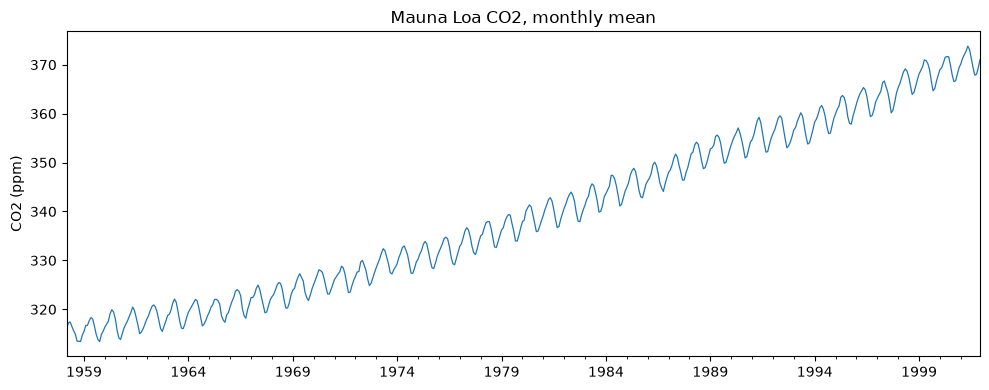

In [2]:
ax = series.plot(figsize=(10, 4), linewidth=0.9, title='Mauna Loa CO2, monthly mean')
ax.set_ylabel('CO2 (ppm)')
plt.tight_layout()

## 2. STL decomposition

`decompose` wraps statsmodels STL. The seasonal strength statistic
(Hyndman's measure) confirms how dominant the yearly cycle is.

seasonal strength: 0.984


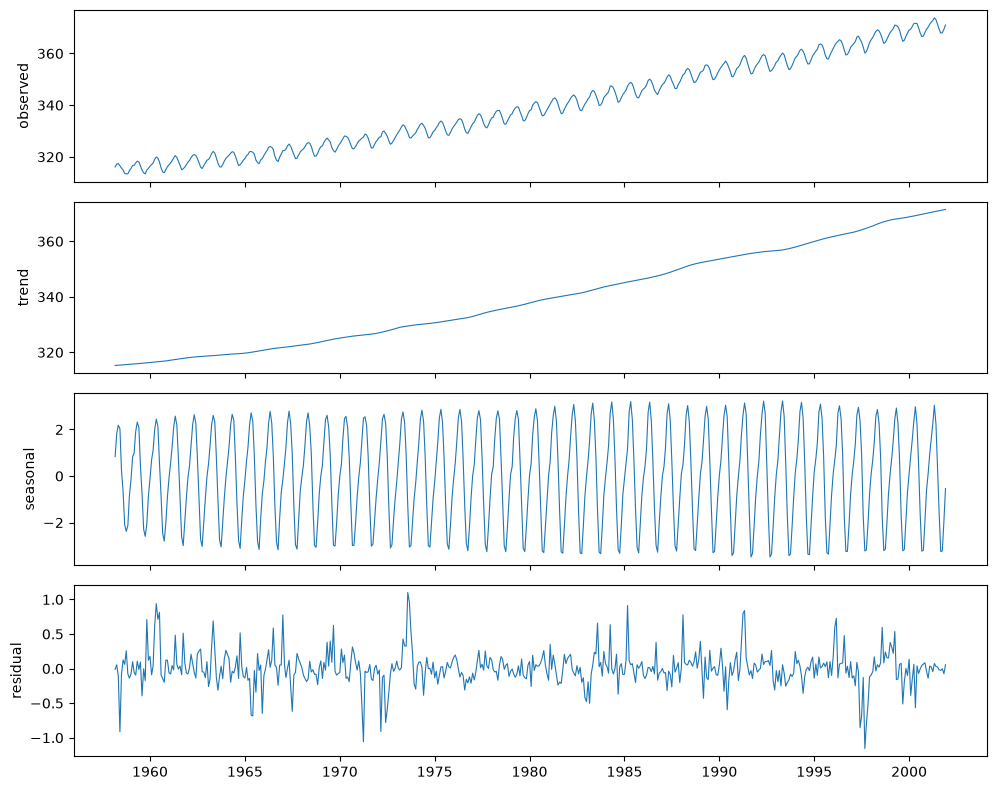

In [3]:
dec = decompose(series, period=12, method='stl')
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, comp, name in zip(
    axes,
    (dec.observed, dec.trend, dec.seasonal, dec.resid),
    ('observed', 'trend', 'seasonal', 'residual'),
):
    ax.plot(comp.index, comp.values, linewidth=0.8)
    ax.set_ylabel(name)
plt.tight_layout()
print(f"seasonal strength: {dec.seasonal_strength():.3f}")

## 3. SARIMAX forecast of a held-out year

Train on everything except the last 12 months, then forecast them with a
SARIMAX(1,1,1)x(1,1,1,12) specification.

model AIC: 210.3


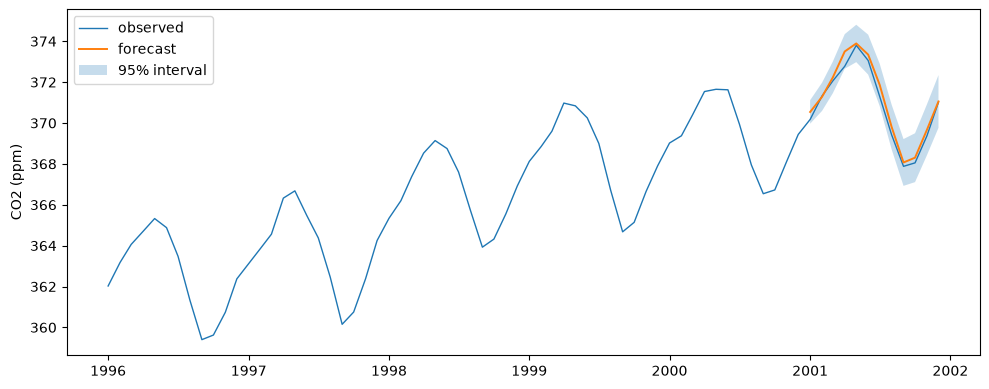

In [4]:
horizon = 12
train, test = series.iloc[:-horizon], series.iloc[-horizon:]
model = SarimaxForecaster(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(train)
fc = model.forecast(steps=horizon)

fig, ax = plt.subplots(figsize=(10, 4))
tail = series.iloc[-72:]
ax.plot(tail.index, tail.values, label='observed', linewidth=1.0)
ax.plot(test.index, fc.mean.values, label='forecast', linewidth=1.4)
ax.fill_between(test.index, fc.lower.values, fc.upper.values, alpha=0.25,
                label='95% interval')
ax.set_ylabel('CO2 (ppm)')
ax.legend()
plt.tight_layout()
print(f"model AIC: {model.aic():.1f}")

## 4. Walk-forward backtest

A single train/test split can flatter a model. The walk-forward backtest
refits on an expanding window and scores every held-out point: here the
last 60 months in five 12-month folds.

In [5]:
result = walk_forward_backtest(
    series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    initial_train_size=len(series) - 60,
    horizon=12,
)
print(result.summary())

5 folds, 60 held-out points | RMSE=0.6559 MAE=0.5064 MAPE=0.138%


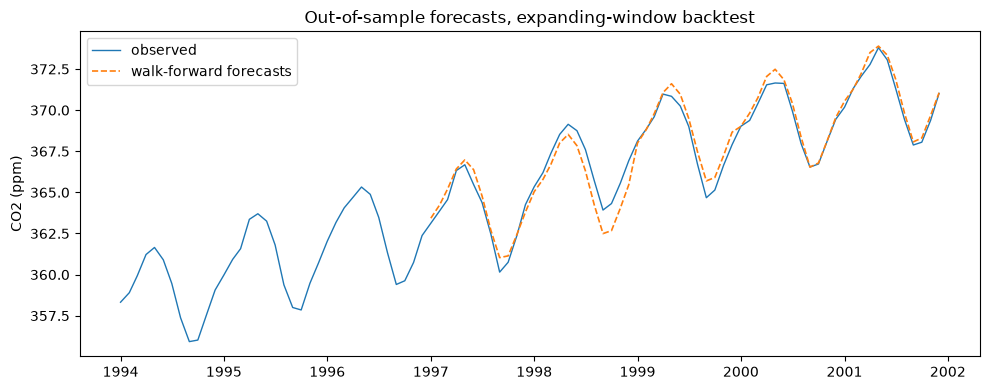

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
actual_window = series.iloc[-96:]
ax.plot(actual_window.index, actual_window.values, label='observed', linewidth=1.0)
ax.plot(result.predictions.index, result.predictions.values,
        label='walk-forward forecasts', linewidth=1.2, linestyle='--')
ax.set_ylabel('CO2 (ppm)')
ax.set_title('Out-of-sample forecasts, expanding-window backtest')
ax.legend()
plt.tight_layout()

The backtest errors are small relative to the series level (around 370 ppm),
which is expected for a series this regular. The same API works on any
regular pandas Series, for example the optional FRED macro series fetched
by `scripts/download_data.py`.